In [1]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import shutil
import os
import json

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
CONFIG = {
    "drive_train_dir": "/content/drive/MyDrive/Emotions Dataset/train",
    "drive_validation_dir": "/content/drive/MyDrive/Emotions Dataset/test",
    "local_train_dir": "/content/train",
    "local_validation_dir": "/content/validation",
    "image_size": (224, 224),
    "batch_size": 32,
    "num_classes": 3,
    "class_names": ["angry", "happy", "sad"],
    "epochs": 30,
    "learning_rate": 0.001,
    "model_type": "baseline_normal"
}

In [4]:
print("Copying data from Google Drive to local Colab storage")

# Copy data from Drive to local Colab storage for faster access
if not os.path.exists(CONFIG["local_train_dir"]):
    print("Copying training data to local storage")
    shutil.copytree(CONFIG["drive_train_dir"], CONFIG["local_train_dir"])
    print("Training data copied successfully")

if not os.path.exists(CONFIG["local_validation_dir"]):
    print("Copying validation data to local storage")
    shutil.copytree(CONFIG["drive_validation_dir"], CONFIG["local_validation_dir"])
    print("Validation data copied successfully")

Copying data from Google Drive to local Colab storage
Copying training data to local storage
Training data copied successfully
Copying validation data to local storage
Validation data copied successfully


In [5]:
print("Step 1: Loading pre-trained EfficientNetB0")

# Create the model architecture without weights
base_model = EfficientNetB0(weights=None,
                            include_top=False)

# Build the model with the correct shape
batch_input_shape = (None, 256, 256, 3)
base_model.build(batch_input_shape)

# Load the weights
weights_path = tf.keras.utils.get_file(
    'efficientnetb0_notop.h5',
    'https://storage.googleapis.com/keras-applications/efficientnetb0_notop.h5',
    cache_subdir='models'
)
base_model.load_weights(weights_path)

base_model.trainable = False

print(f"Number of layers: {len(base_model.layers)}")

Step 1: Loading pre-trained EfficientNetB0
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Number of layers: 237


In [6]:
print("Step 2: Preparing data generators")

# No data augmentation, no low-light techniques
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
)

# Validation data generator (standard preprocessing)
validation_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# Create data generators
train_generator = train_datagen.flow_from_directory(
    CONFIG["local_train_dir"],
    target_size=CONFIG["image_size"],
    batch_size=CONFIG["batch_size"],
    class_mode='categorical',
    color_mode='rgb',
    shuffle=True,
    classes=CONFIG["class_names"]
)

validation_generator = validation_datagen.flow_from_directory(
    CONFIG["local_validation_dir"],
    target_size=CONFIG["image_size"],
    batch_size=CONFIG["batch_size"],
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False,
    classes=CONFIG["class_names"]
)

print(f"Training samples: {train_generator.samples}")
print(f"Validation samples: {validation_generator.samples}")
print(f"Class indices: {train_generator.class_indices}")

Step 2: Preparing data generators
Found 6799 images belonging to 3 classes.
Found 2278 images belonging to 3 classes.
Training samples: 6799
Validation samples: 2278
Class indices: {'angry': 0, 'happy': 1, 'sad': 2}


In [7]:
print("Step 3: Building the model architecture")


model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(CONFIG["num_classes"], activation='softmax')
])

model.summary()

Step 3: Building the model architecture


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, None, None,     │     4,049,571 │
│                                 │ 1280)                  │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,378,278 (16.70 MB)

 Trainable params: 328,707 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [8]:
print("Step 4: Compiling the model")

# Callbacks
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    f"baseline_modelA_best.h5",
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.TopKCategoricalAccuracy(k=2, name='top_2_accuracy')]
)

Step 4: Compiling the model


In [9]:
print("Step 5: Training the model")

# Calculate steps per epoch
steps_per_epoch = train_generator.samples // train_generator.batch_size
validation_steps = validation_generator.samples // validation_generator.batch_size

print(f"Steps per epoch: {steps_per_epoch}")
print(f"Validation steps: {validation_steps}")

# Train the model
history = model.fit(
    train_generator,
    epochs=CONFIG["epochs"],
    validation_data=validation_generator,
    callbacks=[checkpoint_callback, early_stopping, reduce_lr],
    verbose=1
)

Step 5: Training the model
Steps per epoch: 212
Validation steps: 71
Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.6028 - loss: 0.8768 - top_2_accuracy: 0.8482
Epoch 1: val_accuracy improved from -inf to 0.74012, saving model to baseline_modelA_best.h5


213/213 ━━━━━━━━━━━━━━━━━━━━ 75s 213ms/step - accuracy: 0.6030 - loss: 0.8764 - top_2_accuracy: 0.8483 - val_accuracy: 0.7401 - val_loss: 0.6261 - val_top_2_accuracy: 0.9157 - learning_rate: 0.0010
Epoch 2/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.7079 - loss: 0.6711 - top_2_accuracy: 0.9131
Epoch 2: val_accuracy improved from 0.74012 to 0.75066, saving model to baseline_modelA_best.h5


213/213 ━━━━━━━━━━━━━━━━━━━━ 13s 62ms/step - accuracy: 0.7079 - loss: 0.6711 - top_2_accuracy: 0.9131 - val_accuracy: 0.7507 - val_loss: 0.6045 - val_top_2_accuracy: 0.9162 - learning_rate: 0.0010
Epoch 3/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.7536 - loss: 0.5867 - top_2_accuracy: 0.9326
Epoch 3: val_accuracy improved from 0.75066 to 0.75988, saving model to baseline_modelA_best.h5


...

213/213 ━━━━━━━━━━━━━━━━━━━━ 13s 63ms/step - accuracy: 0.9020 - loss: 0.2539 - top_2_accuracy: 0.9845 - val_accuracy: 0.8402 - val_loss: 0.4328 - val_top_2_accuracy: 0.9579 - learning_rate: 0.0010
Epoch 22/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9124 - loss: 0.2367 - top_2_accuracy: 0.9833
Epoch 22: val_accuracy did not improve from 0.84021
213/213 ━━━━━━━━━━━━━━━━━━━━ 13s 59ms/step - accuracy: 0.9123 - loss: 0.2367 - top_2_accuracy: 0.9833 - val_accuracy: 0.8332 - val_loss: 0.4607 - val_top_2_accuracy: 0.9579 - learning_rate: 0.0010
Epoch 23/30
212/213 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9098 - loss: 0.2338 - top_2_accuracy: 0.9844
Epoch 23: val_accuracy improved from 0.84021 to 0.84153, saving model to baseline_modelA_best.h5


213/213 ━━━━━━━━━━━━━━━━━━━━ 13s 62ms/step - accuracy: 0.9097 - loss: 0.2338 - top_2_accuracy: 0.9844 - val_accuracy: 0.8415 - val_loss: 0.4317 - val_top_2_accuracy: 0.9508 - learning_rate: 0.0010
Epoch 24/30
212/213 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.9126 - loss: 0.2275 - top_2_accuracy: 0.9889
Epoch 24: val_accuracy did not improve from 0.84153
213/213 ━━━━━━━━━━━━━━━━━━━━ 14s 64ms/step - accuracy: 0.9126 - loss: 0.2276 - top_2_accuracy: 0.9889 - val_accuracy: 0.8323 - val_loss: 0.4754 - val_top_2_accuracy: 0.9482 - learning_rate: 0.0010
Epoch 25/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9060 - loss: 0.2405 - top_2_accuracy: 0.9834
Epoch 25: val_accuracy improved from 0.84153 to 0.84284, saving model to baseline_modelA_best.h5


213/213 ━━━━━━━━━━━━━━━━━━━━ 14s 63ms/step - accuracy: 0.9060 - loss: 0.2404 - top_2_accuracy: 0.9834 - val_accuracy: 0.8428 - val_loss: 0.4436 - val_top_2_accuracy: 0.9574 - learning_rate: 0.0010
Epoch 26/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9131 - loss: 0.2351 - top_2_accuracy: 0.9840
Epoch 26: val_accuracy did not improve from 0.84284
213/213 ━━━━━━━━━━━━━━━━━━━━ 14s 65ms/step - accuracy: 0.9131 - loss: 0.2350 - top_2_accuracy: 0.9840 - val_accuracy: 0.8415 - val_loss: 0.4520 - val_top_2_accuracy: 0.9552 - learning_rate: 0.0010
Epoch 27/30
212/213 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9192 - loss: 0.2172 - top_2_accuracy: 0.9860
Epoch 27: val_accuracy improved from 0.84284 to 0.84460, saving model to baseline_modelA_best.h5


213/213 ━━━━━━━━━━━━━━━━━━━━ 14s 63ms/step - accuracy: 0.9192 - loss: 0.2173 - top_2_accuracy: 0.9860 - val_accuracy: 0.8446 - val_loss: 0.4391 - val_top_2_accuracy: 0.9543 - learning_rate: 0.0010
Epoch 28/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9217 - loss: 0.2084 - top_2_accuracy: 0.9883
Epoch 28: val_accuracy improved from 0.84460 to 0.85119, saving model to baseline_modelA_best.h5



Epoch 28: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
213/213 ━━━━━━━━━━━━━━━━━━━━ 14s 66ms/step - accuracy: 0.9217 - loss: 0.2084 - top_2_accuracy: 0.9883 - val_accuracy: 0.8512 - val_loss: 0.4421 - val_top_2_accuracy: 0.9622 - learning_rate: 0.0010
Epoch 29/30
212/213 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9289 - loss: 0.1868 - top_2_accuracy: 0.9880
Epoch 29: val_accuracy did not improve from 0.85119
213/213 ━━━━━━━━━━━━━━━━━━━━ 13s 61ms/step - accuracy: 0.9289 - loss: 0.1868 - top_2_accuracy: 0.9880 - val_accuracy: 0.8512 - val_loss: 0.4450 - val_top_2_accuracy: 0.9574 - learning_rate: 5.0000e-04
Epoch 30/30
212/213 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9307 - loss: 0.1877 - top_2_accuracy: 0.9906
Epoch 30: val_accuracy did not improve from 0.85119
213/213 ━━━━━━━━━━━━━━━━━━━━ 14s 67ms/step - accuracy: 0.9307 - loss: 0.1878 - top_2_accuracy: 0.9906 - val_accuracy: 0.8503 - val_loss: 0.4516 - val_top_2_accuracy: 0.9579 - learning_rate: 5.00

In [10]:
print("Step 7: Saving baseline results and metrics")

# Save the trained model
model.save("emotion_baseline_modelA.h5")
print("Baseline model saved!")

# Save training history
baseline_history = {
    'config': CONFIG,
    'training_accuracy': history.history['accuracy'],
    'training_loss': history.history['loss'],
    'training_top2_accuracy': history.history['top_2_accuracy'],
    'validation_accuracy': history.history['val_accuracy'],
    'validation_loss': history.history['val_loss'],
    'validation_top2_accuracy': history.history['val_top_2_accuracy'],
    'final_epochs': len(history.history['accuracy'])
}

with open('baselineA_training_history.json', 'w') as f:
    json.dump(baseline_history, f, indent=4)

print("Training history saved!")

Step 7: Saving baseline results and metrics
Baseline model saved!
Training history saved!


In [11]:
print("Final Model Performance:")
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
print(f"Training Accuracy: {final_train_acc:.4f}")
print(f"Validation Accuracy: {final_val_acc:.4f}")

Final Model Performance:
Training Accuracy: 0.9269
Validation Accuracy: 0.8503


Step 8: Plotting and analyzing baseline results


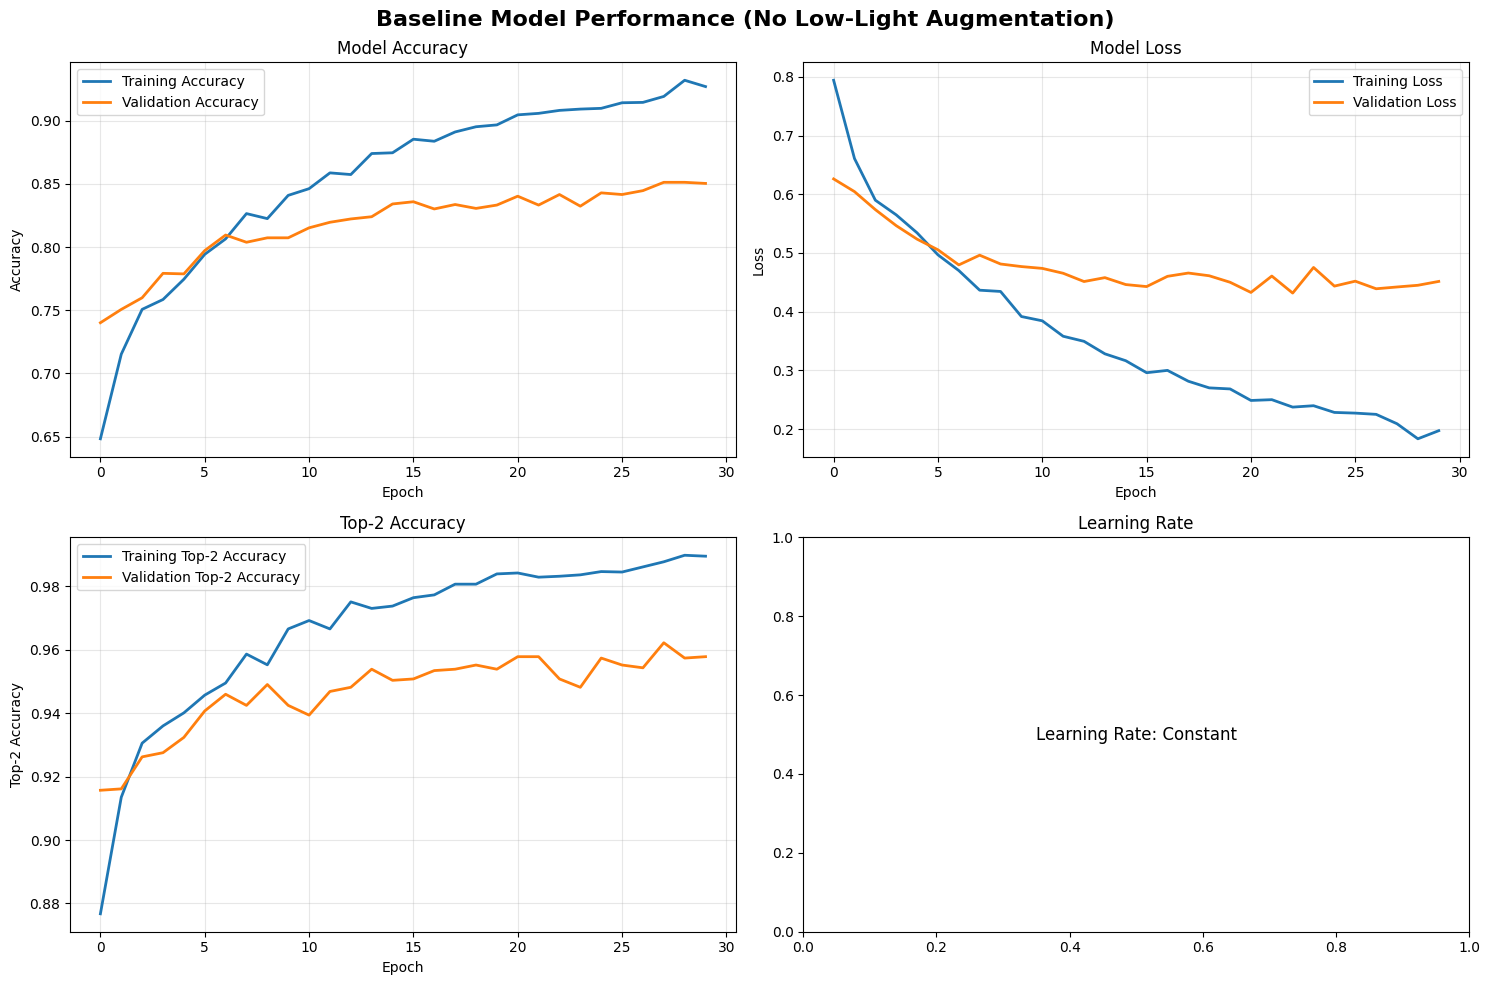

In [12]:
print("Step 8: Plotting and analyzing baseline results")

# Create plots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Baseline Model Performance (No Low-Light Augmentation)', fontsize=16, fontweight='bold')

# Accuracy plot
axes[0, 0].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[0, 0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0, 0].set_title('Model Accuracy')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Loss plot
axes[0, 1].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0, 1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0, 1].set_title('Model Loss')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Top-2 Accuracy plot
axes[1, 0].plot(history.history['top_2_accuracy'], label='Training Top-2 Accuracy', linewidth=2)
axes[1, 0].plot(history.history['val_top_2_accuracy'], label='Validation Top-2 Accuracy', linewidth=2)
axes[1, 0].set_title('Top-2 Accuracy')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Top-2 Accuracy')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Learning rate plot
if 'lr' in history.history:
    axes[1, 1].plot(history.history['lr'], label='Learning Rate', linewidth=2, color='red')
    axes[1, 1].set_title('Learning Rate Schedule')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Learning Rate')
    axes[1, 1].set_yscale('log')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
else:
    axes[1, 1].text(0.5, 0.5, 'Learning Rate: Constant',
                   horizontalalignment='center', verticalalignment='center',
                   transform=axes[1, 1].transAxes, fontsize=12)
    axes[1, 1].set_title('Learning Rate')

plt.tight_layout()
plt.savefig('baselineA_performance.png', dpi=300, bbox_inches='tight')
plt.show()


In [13]:
print("Step 9: Final baseline model evaluation")

# Calculate final metrics
final_train_accuracy = history.history['accuracy'][-1]
final_val_accuracy = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print("\n" + "="*60)
print("BASELINE MODEL FINAL RESULTS")
print("="*60)
print(f"Final Training Accuracy: {final_train_accuracy:.4f}")
print(f"Final Validation Accuracy: {final_val_accuracy:.4f}")
print(f"Final Training Loss: {final_train_loss:.4f}")
print(f"Final Validation Loss: {final_val_loss:.4f}")
print(f"Training Epochs: {len(history.history['accuracy'])}")
print(f"Best Validation Accuracy: {max(history.history['val_accuracy']):.4f}")
print("="*60)

# Save final results summary
results_summary = {
    'model_type': 'baseline_normal',
    'final_training_accuracy': float(final_train_accuracy),
    'final_validation_accuracy': float(final_val_accuracy),
    'final_training_loss': float(final_train_loss),
    'final_validation_loss': float(final_val_loss),
    'best_validation_accuracy': float(max(history.history['val_accuracy'])),
    'total_epochs_trained': len(history.history['accuracy']),
    'dataset_info': {
        'training_samples': train_generator.samples,
        'validation_samples': validation_generator.samples,
        'class_names': CONFIG["class_names"]
    }
}

with open('baselineA_results_summary.json', 'w') as f:
    json.dump(results_summary, f, indent=4)

Step 9: Final baseline model evaluation

BASELINE MODEL FINAL RESULTS
Final Training Accuracy: 0.9269
Final Validation Accuracy: 0.8503
Final Training Loss: 0.1974
Final Validation Loss: 0.4516
Training Epochs: 30
Best Validation Accuracy: 0.8512
